# LSTM Regression Permutation Importance

## 1) Setup

In [11]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from src.utils.runtime_utils import resolve_project_root

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.train.config_setup import load_and_prepare_model
from src.data.preparation_modules.lstm import prepare_data_lstm
from src.utils.metrics import regression_metrics
from src.utils.file_utils import find_latest_model_path

print(f'PROJECT_ROOT: {PROJECT_ROOT}')


PROJECT_ROOT: /root/autodl-tmp/em_eqf


## 2) Config

In [12]:
MANUAL_CHECKPOINT_DIR = 'checkpoints/lstm_20260507-191427'
CHECKPOINT_FILE = 'best_model_1.pth'
USE_TORCH_COMPILE = False
EVAL_BATCH_SIZE = 256
MAX_TEST_SAMPLES = None
N_REPEATS = 8
RANDOM_SEED = 42
PREDICT_BATCH_SIZE = 512
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'DEVICE: {DEVICE}')

DEVICE: cuda:0


## 3) Load Checkpoint + Data

In [13]:
def resolve_checkpoint_dir(manual_checkpoint_dir, project_root: Path) -> Path:
    if manual_checkpoint_dir is None:
        latest_dir = find_latest_model_path('lstm', checkpoint_root=str(project_root / 'checkpoints'))
        return Path(latest_dir)

    ckpt_dir = Path(manual_checkpoint_dir)
    if not ckpt_dir.is_absolute():
        # Always resolve relative path from project root, not notebook cwd.
        ckpt_dir = (project_root / ckpt_dir).resolve()
    return ckpt_dir


CHECKPOINT_DIR = resolve_checkpoint_dir(MANUAL_CHECKPOINT_DIR, PROJECT_ROOT)

candidate_files = [CHECKPOINT_FILE]
if CHECKPOINT_FILE == 'best_model_1.pth':
    candidate_files.append('last_model_1.pth')

CHECKPOINT_PATH = None
for name in candidate_files:
    pth = CHECKPOINT_DIR / name
    if pth.exists():
        CHECKPOINT_PATH = pth
        break

if CHECKPOINT_PATH is None:
    existing = [x.name for x in CHECKPOINT_DIR.glob('*.pth')] if CHECKPOINT_DIR.exists() else []
    raise FileNotFoundError(
        f'Checkpoint not found in {CHECKPOINT_DIR}. '        f'Tried {candidate_files}; existing: {existing[:10]}'
    )

model, args = load_and_prepare_model(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)
args.batch_size = EVAL_BATCH_SIZE

base_dir = PROJECT_ROOT / 'data' / args.dataset
# Use the refactored LSTM preparation module directly.
(
    features_meta,
    train_loader,
    val_loader,
    test_loader,
    dataset,
    feature_frame,
) = prepare_data_lstm(args, base_dir, return_feature_frame=True)

print(f'Loaded checkpoint: {CHECKPOINT_PATH}')
print(f'Dataset: {args.dataset}')
print(f'Feature count: {len(args.feature_cols)}')
print(f'Sequence length: {dataset.X.shape[1]}')
print(f'Train/Val/Test batches: {len(train_loader)}/{len(val_loader)}/{len(test_loader)}')
print(f'Feature frame shape: {feature_frame.shape}')


X shape: (1819, 5, 22), y shape: (1819,)
X_nl shape: (1819, 5, 22), y_nl shape: (1819,)
Loaded checkpoint: /root/autodl-tmp/em_eqf/checkpoints/lstm_20260507-191427/best_model_1.pth
Dataset: ChuanDian
Feature count: 22
Sequence length: 5
Train/Val/Test batches: 6/1/1
Feature frame shape: (1819, 24)


In [14]:
args.t_elaps_mode

'window'

In [15]:
feature_frame.head()

,t,Num,Mag_max,Mag_mean,b_lsq,a_lsq,b_std_lsq,std_gr_lsq,b_mlk,a_mlk,...,Energy_sqrt,prob_x7_lsq,prob_x7_mlk,beta,zvalue,T_elaps5.5,T_elaps6,T_elaps6.5,T_elaps7,Mag_max_obs
0,404.04206,152.0,6.2,3.447368,0.611902,-1.781048,0.227602,1.409652,0.970776,5.094171,...,4.744190e+11,0.014598,0.001224,-1.361114,0.177162,3.326383,349.62015,NaN,NaN,5.3
1,414.04206,152.0,6.2,3.453289,0.615471,-1.793185,0.229563,1.425089,0.958095,5.056129,...,4.744464e+11,0.014243,0.001336,-1.361114,0.173260,13.326383,359.62015,NaN,NaN,5.9
2,424.04206,148.0,5.9,3.427027,0.656997,-1.861773,0.247039,1.345428,1.017019,5.221318,...,2.833092e+11,0.010691,0.000889,-1.395060,0.152867,23.326383,NaN,NaN,NaN,5.9
3,434.04206,146.0,5.8,3.402055,0.748598,-2.293055,0.317209,1.634447,1.080187,5.404915,...,1.956792e+11,0.005678,0.000575,-1.412473,0.165719,33.326383,NaN,NaN,NaN,5.9
4,444.04206,139.0,5.8,3.376978,0.726115,-2.232304,0.302868,1.538671,1.152041,5.599137,...,1.946590e+11,0.006632,0.000350,-0.711670,0.116248,43.326383,NaN,NaN,NaN,5.9


## 4) Baseline Metrics on Test

In [16]:
def get_root_dataset(loader):
    dataset_ref = loader.dataset
    while isinstance(dataset_ref, torch.utils.data.Subset):
        dataset_ref = dataset_ref.dataset
    return dataset_ref


@torch.no_grad()
def collect_numpy_from_loader(loader, model, device):
    x_all = []
    y_all = []
    p_all = []
    model.eval()

    for x_batch, y_batch in loader:
        pred_batch = model(x_batch.to(device)).detach().cpu().numpy().reshape(-1)
        x_all.append(x_batch.detach().cpu().numpy())
        y_all.append(y_batch.detach().cpu().numpy().reshape(-1))
        p_all.append(pred_batch)

    x_np = np.concatenate(x_all, axis=0)
    y_np = np.concatenate(y_all, axis=0)
    p_np = np.concatenate(p_all, axis=0)
    return x_np, y_np, p_np


root_ds = get_root_dataset(test_loader)
X_test, y_test_norm, pred_test_norm = collect_numpy_from_loader(test_loader, model, DEVICE)

y_test = root_ds.inverse_normalize_label(y_test_norm).numpy().reshape(-1)
y_pred = root_ds.inverse_normalize_label(pred_test_norm).numpy().reshape(-1)

baseline_metrics = regression_metrics(y_test, y_pred, include_dtw=False, include_rank=False)
baseline_metrics

{'RMSE': 0.7307605227755569,
 'MAE': 0.6398615863153844,
 'MSE': 0.5340109416472052,
 'MAPE': 13.7457104091988,
 'R2': -0.5958032503539312,
 'PearsonR': 0.16608188949797664,
 'PearsonR_diff': -0.09762472640683795,
 'DA': 0.03296703296703297}

## 5) LSTM Regression Permutation Importance

In [17]:
@torch.no_grad()
def predict_from_numpy(model, x_np, device, batch_size=512):
    model.eval()
    x_tensor = torch.tensor(x_np, dtype=torch.float32)
    pred_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(x_tensor),
        batch_size=batch_size,
        shuffle=False,
    )

    pred_all = []
    for (x_batch,) in pred_loader:
        pred = model(x_batch.to(device)).detach().cpu().numpy().reshape(-1)
        pred_all.append(pred)

    return np.concatenate(pred_all, axis=0)


def score_regression(y_true, y_pred):
    metrics = regression_metrics(y_true, y_pred, include_dtw=False, include_rank=False)
    return {
        'RMSE': float(metrics['RMSE']),
        'MAE': float(metrics['MAE']),
        'R2': float(metrics['R2']),
    }


def permutation_importance_lstm_regression(
    model,
    x_test_np,
    y_true,
    feature_names,
    root_dataset,
    device,
    n_repeats=8,
    seed=42,
    batch_size=512,
):
    rng = np.random.default_rng(seed)

    base_pred_norm = predict_from_numpy(model, x_test_np, device=device, batch_size=batch_size)
    base_pred = root_dataset.inverse_normalize_label(base_pred_norm).numpy().reshape(-1)
    base_scores = score_regression(y_true, base_pred)

    rows = []
    raw = {}

    n_samples = x_test_np.shape[0]

    for feat_idx, feat_name in enumerate(tqdm(feature_names, desc='Permutation features')):
        rmse_deltas = []
        mae_deltas = []
        r2_drops = []

        for _ in range(n_repeats):
            perm_idx = rng.permutation(n_samples)
            x_perm = x_test_np.copy()
            x_perm[:, :, feat_idx] = x_perm[perm_idx, :, feat_idx]

            perm_pred_norm = predict_from_numpy(model, x_perm, device=device, batch_size=batch_size)
            perm_pred = root_dataset.inverse_normalize_label(perm_pred_norm).numpy().reshape(-1)
            perm_scores = score_regression(y_true, perm_pred)

            rmse_deltas.append(float(perm_scores['RMSE'] - base_scores['RMSE']))
            mae_deltas.append(float(perm_scores['MAE'] - base_scores['MAE']))
            r2_drops.append(float(base_scores['R2'] - perm_scores['R2']))

        raw[feat_name] = {
            'delta_rmse': rmse_deltas,
            'delta_mae': mae_deltas,
            'drop_r2': r2_drops,
        }

        rows.append({
            'feature': feat_name,
            'delta_rmse_mean': float(np.mean(rmse_deltas)),
            'delta_rmse_std': float(np.std(rmse_deltas, ddof=1) if n_repeats > 1 else 0.0),
            'delta_mae_mean': float(np.mean(mae_deltas)),
            'delta_mae_std': float(np.std(mae_deltas, ddof=1) if n_repeats > 1 else 0.0),
            'drop_r2_mean': float(np.mean(r2_drops)),
            'drop_r2_std': float(np.std(r2_drops, ddof=1) if n_repeats > 1 else 0.0),
        })

    imp_df = pd.DataFrame(rows).sort_values('delta_rmse_mean', ascending=False).reset_index(drop=True)
    return base_scores, imp_df, raw

In [18]:
X_eval = X_test.copy()
y_eval = y_test.copy()

if MAX_TEST_SAMPLES is not None and MAX_TEST_SAMPLES < len(X_eval):
    subset_rng = np.random.default_rng(RANDOM_SEED)
    subset_idx = subset_rng.choice(len(X_eval), size=int(MAX_TEST_SAMPLES), replace=False)
    X_eval = X_eval[subset_idx]
    y_eval = y_eval[subset_idx]
    print(f'Using subset for permutation: {len(X_eval)} samples')
else:
    print(f'Using full test set for permutation: {len(X_eval)} samples')

base_scores, importance_df, importance_raw = permutation_importance_lstm_regression(
    model=model,
    x_test_np=X_eval,
    y_true=y_eval,
    feature_names=args.feature_cols,
    root_dataset=root_ds,
    device=DEVICE,
    n_repeats=N_REPEATS,
    seed=RANDOM_SEED,
    batch_size=PREDICT_BATCH_SIZE,
)

print('Baseline scores:', base_scores)
importance_df

Using full test set for permutation: 183 samples


Permutation features:   0%|          | 0/22 [00:00<?, ?it/s]

Baseline scores: {'RMSE': 0.7307605227755569, 'MAE': 0.6398615863153844, 'R2': -0.5958032503539312}


,feature,delta_rmse_mean,delta_rmse_std,delta_mae_mean,delta_mae_std,drop_r2_mean,drop_r2_std
0,T_elaps5.5,0.106945,0.037188,0.069239,0.022821,0.504878,0.184642
1,a_mlk,0.038604,0.003848,0.032278,0.003393,0.173095,0.017693
2,std_gr_mlk,0.033556,0.005577,0.028142,0.006266,0.150003,0.025463
3,b_std_mlk,0.027756,0.004373,0.024141,0.002979,0.123578,0.019815
4,a_lsq,0.019520,0.005600,0.010106,0.003190,0.086477,0.025175
5,Mag_mean,0.016640,0.001818,0.012957,0.001518,0.073510,0.008102
6,b_mlk,0.012199,0.002347,0.009200,0.002271,0.053740,0.010415
7,prob_x7_lsq,0.005419,0.001155,0.005570,0.001566,0.023759,0.005080
8,prob_x7_mlk,0.002371,0.000712,0.002861,0.000526,0.010372,0.003119
9,std_gr_lsq,0.001959,0.003152,0.001661,0.002276,0.008592,0.013806


## 6) Plot + Save Results

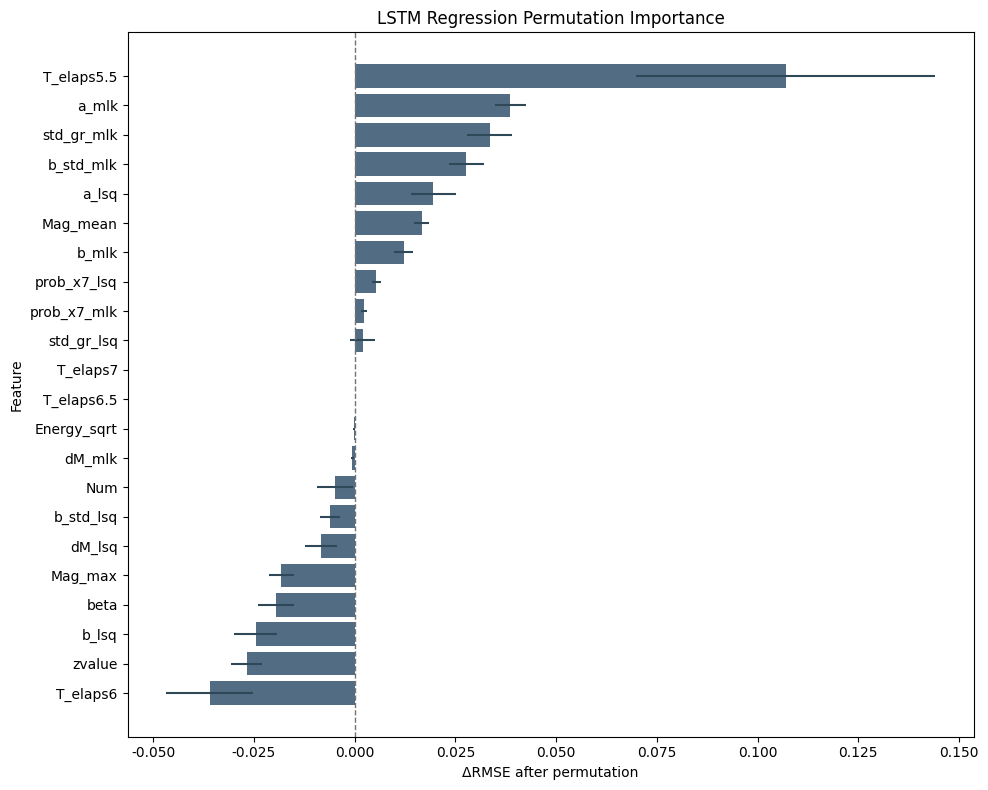

Saved figure: /root/autodl-tmp/em_eqf/checkpoints/lstm_20260507-191427/analysis/lstm_permutation_importance/lstm_permutation_importance_rmse.png
Saved table: /root/autodl-tmp/em_eqf/checkpoints/lstm_20260507-191427/analysis/lstm_permutation_importance/lstm_permutation_importance.csv
Saved raw details: /root/autodl-tmp/em_eqf/checkpoints/lstm_20260507-191427/analysis/lstm_permutation_importance/lstm_permutation_importance_raw.json
Saved baseline metrics: /root/autodl-tmp/em_eqf/checkpoints/lstm_20260507-191427/analysis/lstm_permutation_importance/baseline_metrics.json


In [19]:
OUT_DIR = CHECKPOINT_DIR / 'analysis' / 'lstm_permutation_importance'
OUT_DIR.mkdir(parents=True, exist_ok=True)

plot_df = importance_df.sort_values('delta_rmse_mean', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(
    plot_df['feature'],
    plot_df['delta_rmse_mean'],
    xerr=plot_df['delta_rmse_std'],
    color='#3E5C76',
    ecolor='#2F4858',
    alpha=0.9,
)
plt.axvline(0.0, color='0.45', linestyle='--', linewidth=1)
plt.xlabel('ΔRMSE after permutation')
plt.ylabel('Feature')
plt.title('LSTM Regression Permutation Importance')
plt.tight_layout()

fig_path = OUT_DIR / 'lstm_permutation_importance_rmse.png'
csv_path = OUT_DIR / 'lstm_permutation_importance.csv'
raw_path = OUT_DIR / 'lstm_permutation_importance_raw.json'
metrics_path = OUT_DIR / 'baseline_metrics.json'

plt.savefig(fig_path, dpi=220)
plt.show()

importance_df.to_csv(csv_path, index=False)
with open(raw_path, 'w', encoding='utf-8') as f:
    json.dump(importance_raw, f, indent=2)
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(base_scores, f, indent=2)

print(f'Saved figure: {fig_path}')
print(f'Saved table: {csv_path}')
print(f'Saved raw details: {raw_path}')
print(f'Saved baseline metrics: {metrics_path}')

## 7) Optional: Feature × Time-Step Permutation Heatmap

Feature x step:   0%|          | 0/22 [00:00<?, ?it/s]

,t-0,t-1,t-2,t-3,t-4
Num,-0.004443,-0.005720,-0.002642,-0.003927,-0.005923
Mag_max,-0.005434,-0.005811,-0.005521,-0.004947,0.001229
Mag_mean,0.005805,0.004462,0.002919,0.002991,0.003134
b_lsq,-0.009167,-0.008816,-0.008661,-0.010002,-0.000635
a_lsq,0.006770,0.006356,0.002314,0.002154,-0.000769
b_std_lsq,-0.001331,-0.001959,-0.003540,-0.005201,0.000900
std_gr_lsq,0.000874,0.000756,0.000675,-0.000901,-0.001828
b_mlk,0.003674,0.004455,0.003484,0.001602,0.000917
a_mlk,0.009963,0.009082,0.006688,0.005952,0.007793
b_std_mlk,0.006335,0.006040,0.006040,0.004801,0.002706


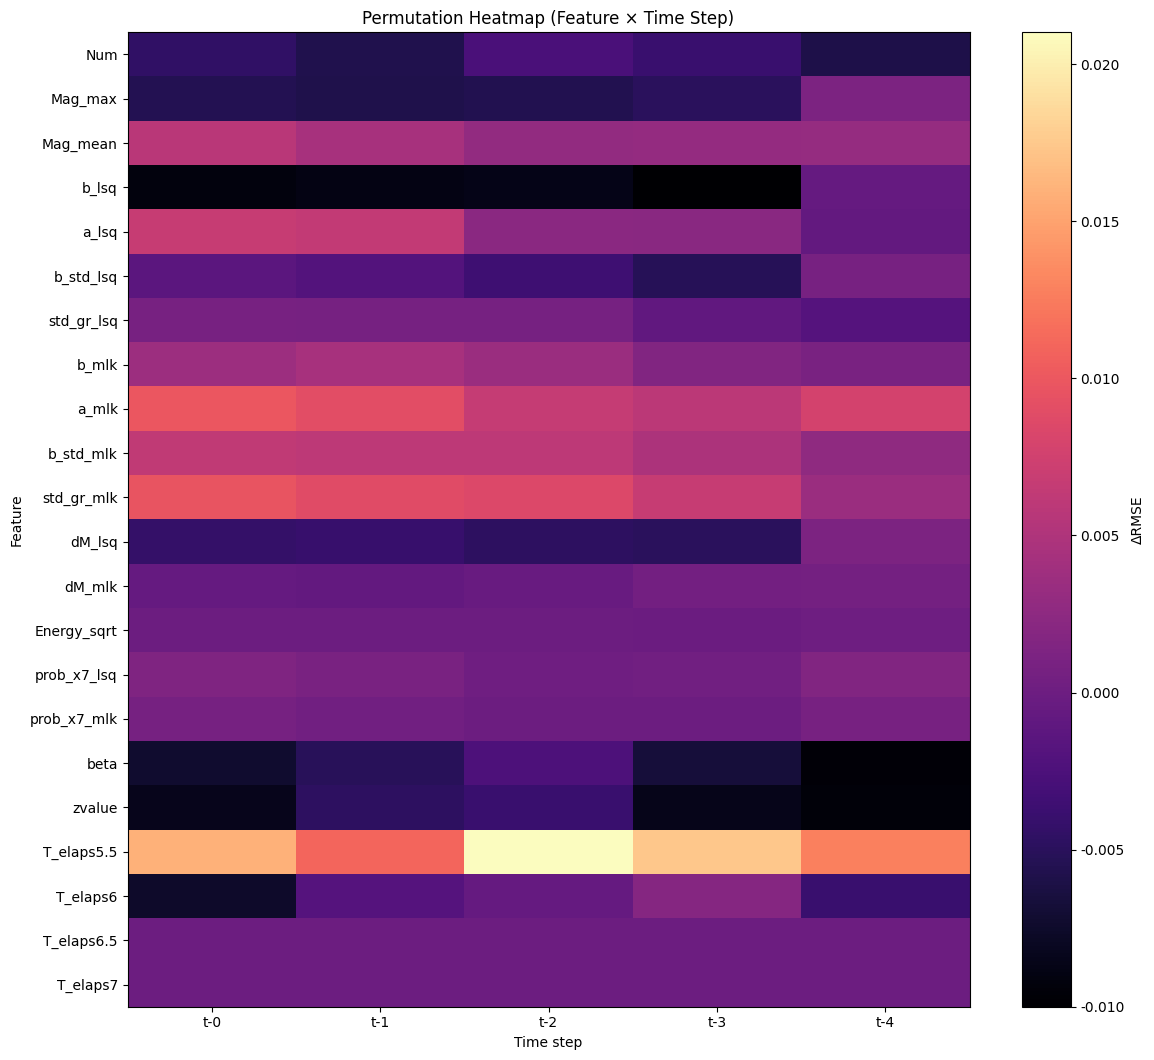

Saved heatmap figure: /root/autodl-tmp/em_eqf/checkpoints/lstm_20260507-191427/analysis/lstm_permutation_importance/lstm_permutation_importance_heatmap.png
Saved heatmap csv: /root/autodl-tmp/em_eqf/checkpoints/lstm_20260507-191427/analysis/lstm_permutation_importance/lstm_permutation_importance_heatmap.csv


In [20]:
RUN_TIMESTEP_IMPORTANCE = True
TS_REPEATS = 4

if RUN_TIMESTEP_IMPORTANCE:
    n_samples, seq_len, n_features = X_eval.shape
    time_rng = np.random.default_rng(RANDOM_SEED)

    base_pred_norm = predict_from_numpy(model, X_eval, device=DEVICE, batch_size=PREDICT_BATCH_SIZE)
    base_pred = root_ds.inverse_normalize_label(base_pred_norm).numpy().reshape(-1)
    base_metric = score_regression(y_eval, base_pred)

    heat = np.zeros((n_features, seq_len), dtype=float)

    for f_idx, feat_name in enumerate(tqdm(args.feature_cols, desc='Feature x step')):
        for t_idx in range(seq_len):
            deltas = []
            for _ in range(TS_REPEATS):
                perm_idx = time_rng.permutation(n_samples)
                x_perm = X_eval.copy()
                x_perm[:, t_idx, f_idx] = x_perm[perm_idx, t_idx, f_idx]

                perm_pred_norm = predict_from_numpy(model, x_perm, device=DEVICE, batch_size=PREDICT_BATCH_SIZE)
                perm_pred = root_ds.inverse_normalize_label(perm_pred_norm).numpy().reshape(-1)
                perm_metric = score_regression(y_eval, perm_pred)
                deltas.append(float(perm_metric['RMSE'] - base_metric['RMSE']))

            heat[f_idx, t_idx] = float(np.mean(deltas))

    heat_df = pd.DataFrame(heat, index=args.feature_cols, columns=[f't-{i}' for i in range(seq_len)])
    display(heat_df)

    plt.figure(figsize=(1.6 * seq_len + 4, 0.35 * n_features + 3))
    image = plt.imshow(heat_df.values, aspect='auto', cmap='magma')
    plt.colorbar(image, label='ΔRMSE')
    plt.xticks(np.arange(seq_len), heat_df.columns)
    plt.yticks(np.arange(n_features), heat_df.index)
    plt.xlabel('Time step')
    plt.ylabel('Feature')
    plt.title('Permutation Heatmap (Feature × Time Step)')
    plt.tight_layout()

    heat_fig_path = OUT_DIR / 'lstm_permutation_importance_heatmap.png'
    heat_csv_path = OUT_DIR / 'lstm_permutation_importance_heatmap.csv'
    plt.savefig(heat_fig_path, dpi=220)
    plt.show()

    heat_df.to_csv(heat_csv_path)
    print(f'Saved heatmap figure: {heat_fig_path}')
    print(f'Saved heatmap csv: {heat_csv_path}')
else:
    print('Skip time-step heatmap. Set RUN_TIMESTEP_IMPORTANCE=True to run.')